In [ ]:
# environment setup using python virtual environments and pip package manager
%pip install pandas seaborn matplotlib numpy Ipython kagglehub scikit-learn

### Assignment 4  - CSI4142
Student names: Sameed Jafri (300253861), Jaime Bly (300231604)

Group number: 36

work spilt:
- Study 2 and 4: Jamie Bly
- Study 1 and 3: Sameed Jafri



## Dataset Description

### Name & Author
**The Movies Dataset** — compiled by **Rounak Banik**, published on Kaggle (`rounakbanik/the-movies-dataset`).  
Data sourced from the [TMDB (The Movie Database)](https://www.themoviedb.org/) public API, covering films released up to July 2017.

### Purpose
The dataset was created to support research and experimentation in **movie recommendation systems** and **data-driven film analysis**. It bundles metadata (genres, budget, revenue, cast, crew, ratings) into a single resource to enable tasks such as content-based filtering, collaborative filtering, and exploratory analysis of what attributes contribute to a film's commercial or critical success.

### Shape

| | Value |
|---|---|
| **Raw rows** | 45,466 movies |
| **Columns (raw)** | 24 |
| **Rows after cleaning** | 5,358 movies |
| **Columns after cleaning** | 28 (24 original + `genres_parsed`, `budget_norm`, `revenue_norm`, `runtime_norm`) |
| **Rows removed** | 40,108 (88.2% of raw) |

> **Note on data loss:** The high removal rate is expected and well-documented for this dataset. The vast majority of TMDB entries have `budget = 0` and/or `revenue = 0` because studios do not consistently report financial data publicly — these zeros are placeholders, not real values. Only films with verified financial records are retained, yielding a reliable working set of 5,358 movies.

### Features

| # | Column | Type | Description |
|---|--------|------|-------------|
| 1 | `title` | Textual | English release title of the movie |
| 2 | `genres` | Categorical (JSON) | Stringified list of genre dicts, e.g. `[{"id":28,"name":"Action"}]` |
| 3 | `budget` | Numerical (continuous) | Production budget in USD |
| 4 | `revenue` | Numerical (continuous) | Worldwide box-office revenue in USD |
| 5 | `runtime` | Numerical (continuous) | Film duration in minutes |
| 6 | `vote_average` | Numerical (continuous) | Mean user rating on TMDB (0–10 scale) |
| 7 | `vote_count` | Numerical (discrete) | Number of user ratings submitted |
| 8 | `popularity` | Numerical (continuous) | TMDB internal popularity score |
| 9 | `release_date` | Categorical (date) | Release date (YYYY-MM-DD format) |
| 10 | `original_language` | Categorical | ISO 639-1 language code of the original production |
| 11 | `original_title` | Textual | Title in the original production language |
| 12 | `overview` | Textual | Plot synopsis / description |
| 13 | `tagline` | Textual | Marketing tagline |
| 14 | `status` | Categorical | Release status (e.g. *Released*, *In Production*) |
| 15 | `adult` | Categorical (boolean) | Whether the film is adult-rated |
| 16 | `video` | Categorical (boolean) | Whether the entry is a video release (not a theatrical film) |
| 17 | `belongs_to_collection` | Categorical (JSON) | Franchise/collection the film belongs to (if any) |
| 18 | `production_companies` | Categorical (JSON) | List of producing studios |
| 19 | `production_countries` | Categorical (JSON) | List of production countries |
| 20 | `spoken_languages` | Categorical (JSON) | Languages spoken in the film |
| 21 | `homepage` | Textual (URL) | Official website URL |
| 22 | `poster_path` | Textual (URL) | Relative TMDB poster image path |
| 23 | `id` | Numerical (identifier) | TMDB movie ID |
| 24 | `imdb_id` | Categorical (identifier) | IMDb movie ID (tt-prefixed string) |
| 25 | `genres_parsed` | Categorical (list) | *Engineered* — parsed genre names as a Python list |
| 26 | `budget_norm` | Numerical (continuous) | *Engineered* — Min-Max normalised budget ∈ [0, 1] |
| 27 | `revenue_norm` | Numerical (continuous) | *Engineered* — Min-Max normalised revenue ∈ [0, 1] |
| 28 | `runtime_norm` | Numerical (continuous) | *Engineered* — Min-Max normalised runtime ∈ [0, 1] |


### Why This Dataset?

This dataset was chosen because it supports all four studies in this assignment:

1. **Attribute diversity** — it contains a natural mix of textual (`title`), categorical (`genres`), and continuous numerical (`budget`, `revenue`, `runtime`, `vote_average`, `popularity`) attributes, providing a variety of data types suitable for different similarity measures, clustering dimensions, and feature engineering.
2. **Built-in user rating data** — alongside the metadata, the dataset includes a separate `ratings.csv` file with millions of user–movie ratings, which directly enables the Utility matrix construction required for collaborative filtering in Study 4.
3. **Scale and coverage** — with 5,358 financially verified films and hundreds of thousands of user ratings spanning decades and genres, the dataset is large enough to produce meaningful clusters (Study 2) and reliable matrix factorisation results (Study 4), while remaining computationally manageable.
4. **Real-world relevance** — movie recommendation is one of the canonical applications of unsupervised learning (e.g. Netflix Prize), making results across all four studies easy to interpret and evaluate qualitatively without specialist domain knowledge.

## Data Preparation

This section is **shared across all studies**. Running the cells below produces a clean `df` that any study can build on directly.

| Cell | Purpose |
|------|---------|
| **1 — Load & EDA (raw)** | Load `movies_metadata.csv`, inspect nulls, distributions, and zero-value counts before any changes |
| **2 — Clean & Scale** | Drop nulls/zeros, parse genres, apply Min-Max normalisation → produces `df` |
| **3 — EDA (clean)** | 5 tests/graphs on the clean data: distributions, scatter, outlier detection, correlation, genre frequency |
| **4 — Feature Engineering** | Derive `profit`, `profit_margin`, `is_profitable`, `decade` |

---

### What each study needs

| Study | Uses `df` from here? | Extra data needed |
|-------|----------------------|-------------------|
| **Study 1** (Similarity — Sameed) | ✅ Yes | TF-IDF matrix built in Study 1 setup cell |
| **Study 2** (Clustering — Jaime) | ✅ Yes | None — use `budget_norm`, `revenue_norm`, `runtime_norm` directly |
| **Study 3** (Recommendation — Sameed) | ✅ Yes | None |
| **Study 4** (Collaborative Filtering — Jaime) | ⚠️ Partial | Requires **`ratings.csv`** from the same Kaggle dataset (see note below) |

> **Study 4 note:** Collaborative filtering is built from *user ratings*, not movie metadata. Load `ratings.csv` from the downloaded dataset path (columns: `userId`, `movieId`, `rating`, `timestamp`). To attach movie titles to recommendations, join on `df['id']` == `ratings['movieId']`. The `path` variable from Cell 1 already points to the correct directory:
> ```python
> ratings = pd.read_csv(os.path.join(path, "ratings.csv"))
> ```

In [27]:
import os
import ast

import numpy as np
import pandas as pd
import kagglehub
from IPython.display import display

# ── Download and load raw dataset ─────────────────────────────────────────────
path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")
csv_path = os.path.join(path, "movies_metadata.csv")
df_raw = pd.read_csv(csv_path, low_memory=False)

print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns\n")

# ── EDA 1: sample rows ────────────────────────────────────────────────────────
print("── Sample rows (raw) ────────────────────────────────────────────────────")
display(df_raw[["title", "genres", "budget", "revenue", "runtime"]].head(8))

# ── EDA 2: missing values in key columns ─────────────────────────────────────
print("\n── Missing values — key columns ─────────────────────────────────────────")
key_cols = ["title", "genres", "budget", "revenue", "runtime",
            "vote_average", "popularity", "release_date", "original_language"]
display(df_raw[key_cols].isnull().sum().rename("null count").to_frame())

# ── EDA 3: descriptive statistics on raw numerical columns ───────────────────
print("\n── Descriptive statistics (raw) ─────────────────────────────────────────")
display(df_raw[["budget", "revenue", "runtime"]].apply(pd.to_numeric, errors="coerce").describe())

# ── EDA 4: zero-value counts (placeholder entries masquerading as valid data) ─
print("\n── Zero-value counts (budget / revenue / runtime) ───────────────────────")
num_raw = df_raw[["budget", "revenue", "runtime"]].apply(pd.to_numeric, errors="coerce")
zero_counts = (num_raw == 0).sum().rename("zero count").to_frame()
zero_counts["% of non-null"] = (zero_counts["zero count"] / num_raw.notna().sum() * 100).round(1)
display(zero_counts)

Shape: 45,466 rows × 24 columns

── Sample rows (raw) ────────────────────────────────────────────────────


,title,genres,budget,revenue,runtime
0,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",30000000,373554033.0,81.0
1,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",65000000,262797249.0,104.0
2,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",0,0.0,101.0
3,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",16000000,81452156.0,127.0
4,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",0,76578911.0,106.0
5,Heat,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",60000000,187436818.0,170.0
6,Sabrina,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",58000000,0.0,127.0
7,Tom and Huck,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",0,0.0,97.0



── Missing values — key columns ─────────────────────────────────────────


,null count
title,6
genres,0
budget,0
revenue,6
runtime,263
vote_average,6
popularity,5
release_date,87
original_language,11



── Descriptive statistics (raw) ─────────────────────────────────────────


,budget,revenue,runtime
count,4.546300e+04,4.546000e+04,45203.000000
mean,4.224579e+06,1.120935e+07,94.128199
std,1.742413e+07,6.433225e+07,38.407810
min,0.000000e+00,0.000000e+00,0.000000
25%,0.000000e+00,0.000000e+00,85.000000
50%,0.000000e+00,0.000000e+00,95.000000
75%,0.000000e+00,0.000000e+00,107.000000
max,3.800000e+08,2.787965e+09,1256.000000



── Zero-value counts (budget / revenue / runtime) ───────────────────────


,zero count,% of non-null
budget,36573,80.4
revenue,38052,83.7
runtime,1558,3.4


In [28]:
from sklearn.preprocessing import MinMaxScaler

# ── Informed by EDA above: drop nulls, coerce types, remove zeros ─────────────
df = df_raw.dropna(subset=["title", "genres", "budget", "revenue", "runtime"]).copy()

for col in ("budget", "revenue", "runtime"):
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["budget", "revenue", "runtime"])
df = df[(df["budget"] > 0) & (df["revenue"] > 0) & (df["runtime"] > 0)]


# ── Parse genres (stringified JSON → list of genre name strings) ──────────────
def parse_genres(genres_str: str) -> list:
    """Return a list of genre name strings from a stringified JSON field."""
    try:
        return [g["name"] for g in ast.literal_eval(genres_str)
                if isinstance(g, dict) and "name" in g]
    except (ValueError, SyntaxError):
        return []


df["genres_parsed"] = df["genres"].apply(parse_genres)
df = df[df["genres_parsed"].map(len) > 0]

# ── Min-Max scale numerical features to [0, 1] ────────────────────────────────
scaler = MinMaxScaler()
df[["budget_norm", "revenue_norm", "runtime_norm"]] = scaler.fit_transform(
    df[["budget", "revenue", "runtime"]]
)

df = df.reset_index(drop=True)

print(f"Clean dataset: {len(df):,} rows × {df.shape[1]} columns")
print(f"Removed : {len(df_raw) - len(df):,} rows ({(1 - len(df)/len(df_raw))*100:.1f}% of raw)\n")
display(df[["title", "genres_parsed", "budget", "revenue", "runtime"]].head(5))

Clean dataset: 5,358 rows × 28 columns
Removed : 40,108 rows (88.2% of raw)



,title,genres_parsed,budget,revenue,runtime
0,Toy Story,"[Animation, Comedy, Family]",30000000,373554033.0,81.0
1,Jumanji,"[Adventure, Fantasy, Family]",65000000,262797249.0,104.0
2,Waiting to Exhale,"[Comedy, Drama, Romance]",16000000,81452156.0,127.0
3,Heat,"[Action, Crime, Drama, Thriller]",60000000,187436818.0,170.0
4,Sudden Death,"[Action, Adventure, Thriller]",35000000,64350171.0,106.0


### Exploratory Data Analysis

The following 5 tests and graphs are performed on the **clean dataset** rather than the raw data. This is an intentional methodological choice: the raw `movies_metadata.csv` contains ~88% of entries with `budget = 0` and/or `revenue = 0` (placeholder values for unreported financials). Running visual EDA on the raw data would cause those zero-entries to dominate every histogram, scatter plot, and correlation — rendering the graphs uninformative.

The tabular EDA in Cell 1 (null counts, zero counts, `.describe()`) was performed on the raw data specifically to *diagnose* these problems and justify the cleaning decisions made in Cell 2. The visual EDA below then explores the structure of the real, financially verified data.

| # | Test | What it shows |
|---|------|---------------|
| 1 | Distribution histograms | Skew in budget, revenue, and runtime |
| 2 | Budget vs. Revenue scatter | Linearity of financial relationship, visual outliers |
| 3 | IQR outlier detection + box plots | Quantifies extreme values per feature |
| 4 | Correlation heatmap | Inter-dependence between numerical features |
| 5 | Genre frequency chart | Categorical balance across the dataset |

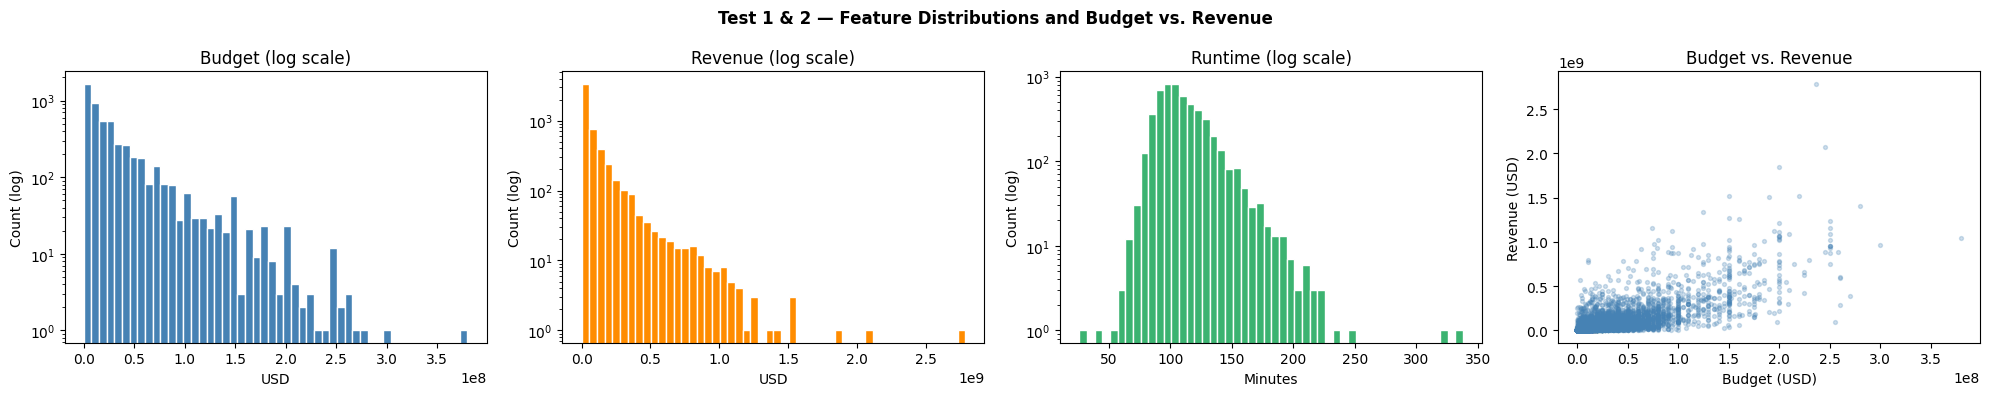

IQR outlier summary:
  budget    :  394 outliers (7.4%)  | IQR range [5,325,000 — 40,000,000]
  revenue   :  533 outliers (9.9%)  | IQR range [7,111,250 — 100,000,000]
  runtime   :  181 outliers (3.4%)  | IQR range [95 — 120]


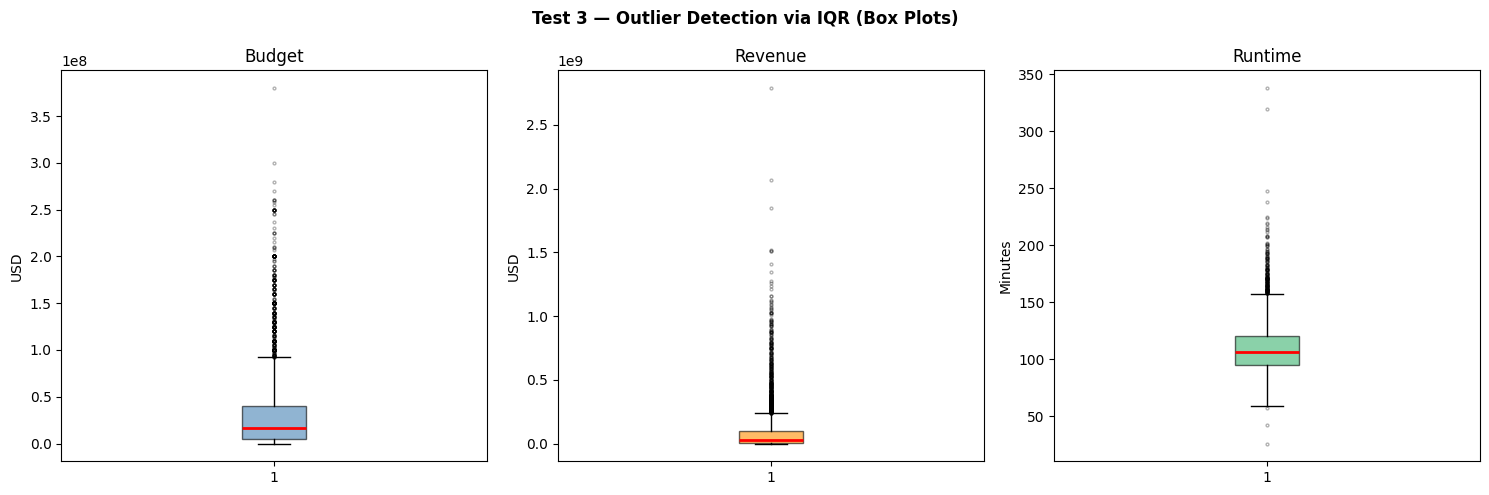

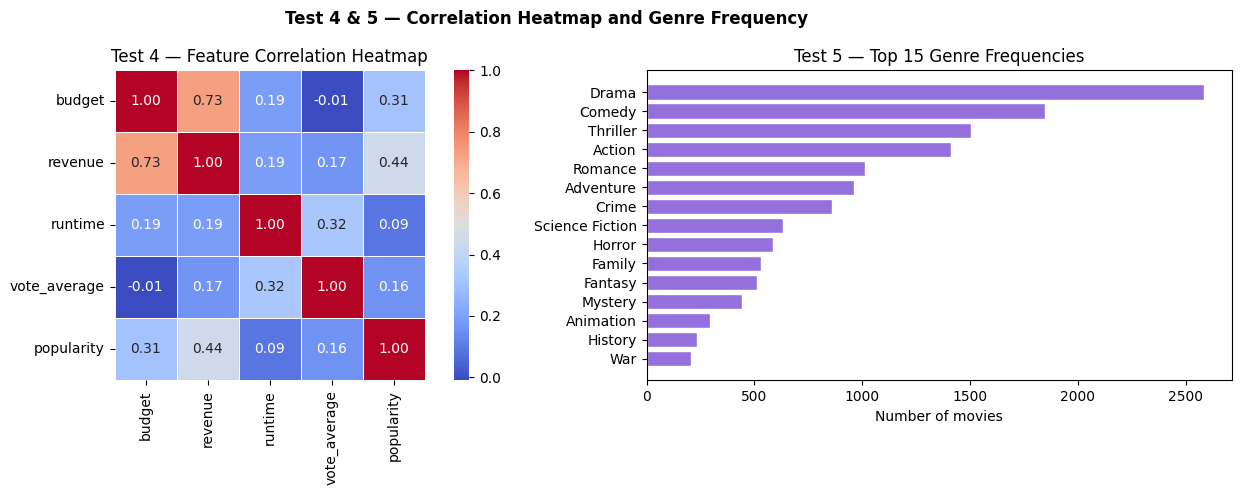

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ── Test 1 & 2: Distributions + Budget vs Revenue ────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Test 1 & 2 — Feature Distributions and Budget vs. Revenue", fontweight="bold")

for ax, col, color in zip(axes[:3],
                          ["budget", "revenue", "runtime"],
                          ["steelblue", "darkorange", "mediumseagreen"]):
    ax.hist(df[col], bins=50, color=color, edgecolor="white", log=True)
    ax.set_title(f"{col.capitalize()} (log scale)")
    ax.set_xlabel("USD" if col != "runtime" else "Minutes")
    ax.set_ylabel("Count (log)")

axes[3].scatter(df["budget"], df["revenue"], alpha=0.25, s=8, color="steelblue")
axes[3].set_title("Budget vs. Revenue")
axes[3].set_xlabel("Budget (USD)")
axes[3].set_ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()

# ── Test 3: IQR Outlier Detection + Box Plots ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Test 3 — Outlier Detection via IQR (Box Plots)", fontweight="bold")

print("IQR outlier summary:")
for ax, col, color in zip(axes,
                          ["budget", "revenue", "runtime"],
                          ["steelblue", "darkorange", "mediumseagreen"]):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", markersize=2, alpha=0.3))
    ax.set_title(col.capitalize())
    ax.set_ylabel("USD" if col != "runtime" else "Minutes")
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col:10s}: {n_out:4d} outliers ({n_out/len(df)*100:.1f}%)  "
          f"| IQR range [{Q1:,.0f} — {Q3:,.0f}]")

# Note: outliers are retained — they represent real blockbuster films (e.g.
# Avatar, Titanic) and removing them would distort recommendation results.
plt.tight_layout()
plt.show()

# ── Test 4: Correlation Heatmap ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Test 4 & 5 — Correlation Heatmap and Genre Frequency", fontweight="bold")

corr_cols = ["budget", "revenue", "runtime", "vote_average", "popularity"]
corr = df[corr_cols].apply(pd.to_numeric, errors="coerce").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title("Test 4 — Feature Correlation Heatmap")

# ── Test 5: Genre Frequency ───────────────────────────────────────────────────
all_genres = [g for genres in df["genres_parsed"] for g in genres]
genre_counts = pd.Series(Counter(all_genres)).sort_values(ascending=True).tail(15)
axes[1].barh(genre_counts.index, genre_counts.values, color="mediumpurple", edgecolor="white")
axes[1].set_title("Test 5 — Top 15 Genre Frequencies")
axes[1].set_xlabel("Number of movies")
plt.tight_layout()
plt.show()

In [30]:
# ── Feature Engineering ───────────────────────────────────────────────────────

# Financial derived features
df["profit"]        = df["revenue"] - df["budget"]
df["profit_margin"] = (df["profit"] / df["budget"]) * 100   # % return on budget
df["is_profitable"] = (df["profit"] > 0).astype(int)        # binary flag

# Decade extracted from release_date (categorical grouping for clustering)
df["decade"] = (
    pd.to_datetime(df["release_date"], errors="coerce")
    .dt.year
    .apply(lambda y: f"{int(y) // 10 * 10}s" if pd.notna(y) else "Unknown")
)

print(f"Columns after feature engineering: {df.shape[1]}")
print(f"Profitable movies: {df['is_profitable'].sum():,} / {len(df):,}  ({df['is_profitable'].mean()*100:.1f}%)")
display(df[["title", "budget", "revenue", "profit", "profit_margin", "decade", "is_profitable"]].head(8))

Columns after feature engineering: 32
Profitable movies: 3,744 / 5,358  (69.9%)


,title,budget,revenue,profit,profit_margin,decade,is_profitable
0,Toy Story,30000000,373554033.0,343554033.0,1145.180110,1990s,1
1,Jumanji,65000000,262797249.0,197797249.0,304.303460,1990s,1
2,Waiting to Exhale,16000000,81452156.0,65452156.0,409.075975,1990s,1
3,Heat,60000000,187436818.0,127436818.0,212.394697,1990s,1
4,Sudden Death,35000000,64350171.0,29350171.0,83.857631,1990s,1
5,GoldenEye,58000000,352194034.0,294194034.0,507.231093,1990s,1
6,The American President,62000000,107879496.0,45879496.0,73.999187,1990s,1
7,Nixon,44000000,13681765.0,-30318235.0,-68.905080,1990s,0


## Study 1: Similarity Measures

This study implements five independent similarity/distance functions, each operating on a **single movie attribute**:

| # | Attribute | Data Type | Measure Applied |
|---|-----------|-----------|-----------------|
| 1 | Title | Textual | Cosine Similarity (TF-IDF word vectors) |
| 2 | Genres | Categorical Set | Jaccard Similarity |
| 3 | Budget | Numerical | Euclidean Distance |
| 4 | Revenue | Numerical | Euclidean Distance |
| 5 | Runtime | Numerical | Manhattan Distance |

All numerical features are Min-Max scaled to `[0, 1]` before distance computation. Each measure is converted to a **similarity score** in `[0, 1]` (higher = more similar). Movie titles are represented as TF-IDF bigram vectors for the cosine measure.

**Simulation:** For each of the five measures, we run a query against the cleaned dataset and display the **Top 10 most similar movies**, ranked by similarity score descending (higher = more similar to the query movie).

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Pre-compute TF-IDF matrix on movie titles (Study 1 — cosine similarity) ───
# Unigram + bigram features capture both individual words and two-word phrases.
# This matrix is used exclusively by title_cosine_sims() in find_top10().
_tfidf_vec = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), sublinear_tf=True)
_tfidf_mat = _tfidf_vec.fit_transform(df["title"].astype(str))
print(f"TF-IDF title matrix: {_tfidf_mat.shape[0]:,} movies × {_tfidf_mat.shape[1]:,} features")

TF-IDF title matrix: 5,358 movies × 11,510 features


In [32]:
from sklearn.metrics.pairwise import cosine_similarity as _sklearn_cosine


# ── 1. Title Similarity: Cosine Similarity on TF-IDF Vectors ─────────────────
def title_cosine_sims(target_idx: int) -> np.ndarray:
    """
    Compute cosine similarity between the target movie's TF-IDF title vector
    and every other movie's vector in the pre-computed matrix.

    Uses the global _tfidf_mat built during data preparation.
    Returns a 1-D array of shape (n_movies,) with scores in [0, 1].
    """
    return _sklearn_cosine(_tfidf_mat[target_idx], _tfidf_mat).flatten()


# ── 2. Genre Similarity: Jaccard Index ───────────────────────────────────────
def genres_jaccard_sim(g1: list, g2: list) -> float:
    """
    Jaccard similarity between two lists of genre name strings.
    J(A, B) = |A ∩ B| / |A ∪ B|.
    Returns 0.0 when both genre sets are empty.
    """
    s1, s2 = set(g1), set(g2)
    if not s1 and not s2:
        return 0.0
    return len(s1 & s2) / len(s1 | s2)


# ── 3. Budget Similarity: Euclidean Distance ──────────────────────────────────
def budget_euclidean_sim(b1: float, b2: float) -> float:
    """
    Euclidean distance on Min-Max normalised budget values (1-dimensional).
    sim = 1 - |b1 - b2|  ∈ [0, 1].
    """
    return 1.0 - abs(b1 - b2)


# ── 4. Revenue Similarity: Euclidean Distance ─────────────────────────────────
def revenue_euclidean_sim(r1: float, r2: float) -> float:
    """
    Euclidean distance on Min-Max normalised revenue values (1-dimensional).
    sim = 1 - |r1 - r2|  ∈ [0, 1].
    """
    return 1.0 - abs(r1 - r2)


# ── 5. Runtime Similarity: Manhattan Distance ──────────────────────────────────
def runtime_manhattan_sim(rt1: float, rt2: float) -> float:
    """
    Manhattan (L1) distance on Min-Max normalised runtime values (1-dimensional).
    In 1D, L1 = |rt1 - rt2|.  Converted to similarity: sim = 1 - |rt1 - rt2|  ∈ [0, 1].
    """
    return 1.0 - abs(rt1 - rt2)


# ── Dispatcher: find Top-10 most similar movies by a single attribute ─────────
_SCALAR_FN = {
    "genres":  lambda row, tgt: genres_jaccard_sim(row["genres_parsed"],   tgt["genres_parsed"]),
    "budget":  lambda row, tgt: budget_euclidean_sim(row["budget_norm"],   tgt["budget_norm"]),
    "revenue": lambda row, tgt: revenue_euclidean_sim(row["revenue_norm"], tgt["revenue_norm"]),
    "runtime": lambda row, tgt: runtime_manhattan_sim(row["runtime_norm"], tgt["runtime_norm"]),
}
_ALL_ATTRIBUTES = {"title"} | set(_SCALAR_FN)


def find_top10(target_title: str, attribute: str, data: pd.DataFrame) -> pd.DataFrame:
    """
    Return the Top 10 movies most similar to *target_title* using *only* the
    specified *attribute* similarity function.

    Parameters
    ----------
    target_title : str          — exact title of the query movie (case-sensitive)
    attribute    : str          — one of 'title', 'genres', 'budget', 'revenue', 'runtime'
    data         : pd.DataFrame — the cleaned movies DataFrame

    Returns
    -------
    pd.DataFrame ranked 1–10 by similarity (target movie excluded).
    Columns: title, genres, budget, revenue, runtime, similarity
    """
    if attribute not in _ALL_ATTRIBUTES:
        raise ValueError(f"Unknown attribute '{attribute}'. Choose from {sorted(_ALL_ATTRIBUTES)}.")

    matches = data[data["title"] == target_title]
    if matches.empty:
        raise ValueError(f"Movie '{target_title}' not found in the dataset.")
    target_idx = matches.index[0]

    if attribute == "title":
        # Vectorised cosine similarity over the full TF-IDF matrix (fast)
        sims = title_cosine_sims(target_idx)
        candidates = data.copy()
        candidates["similarity"] = sims
        candidates = candidates[candidates.index != target_idx]
    else:
        target = data.loc[target_idx]
        sim_fn = _SCALAR_FN[attribute]
        candidates = data[data.index != target_idx].copy()
        candidates["similarity"] = candidates.apply(lambda row: sim_fn(row, target), axis=1)

    top10 = (
        candidates
        .nlargest(10, "similarity")
        [["title", "genres_parsed", "budget", "revenue", "runtime", "similarity"]]
        .rename(columns={"genres_parsed": "genres"})
        .reset_index(drop=True)
    )
    top10.index += 1  # rank from 1
    return top10


print("Similarity functions loaded: Cosine (title), Jaccard (genres), Euclidean (budget/revenue), Manhattan (runtime).")

Similarity functions loaded: Cosine (title), Jaccard (genres), Euclidean (budget/revenue), Manhattan (runtime).


In [33]:
from IPython.display import display

# Five simulations, one per attribute
SIMULATIONS = [
    ("Toy Story",  "title",   "Cosine Similarity (TF-IDF)  →  Title"),
    ("The Dark Knight", "genres",  "Jaccard Similarity          →  Genres"),
    ("Apollo 13",  "budget",  "Euclidean Distance          →  Budget"),
    ("Titanic",    "revenue", "Euclidean Distance          →  Revenue"),
    ("Fight Club", "runtime", "Manhattan Distance          →  Runtime"),
]

for target_title, attribute, label in SIMULATIONS:
    print(f"\n{'═' * 65}")
    print(f"  Query Movie : '{target_title}'")
    print(f"  Measure     : {label}")
    print(f"{'═' * 65}")
    result = find_top10(target_title, attribute, df)
    display(result)


═════════════════════════════════════════════════════════════════
  Query Movie : 'Toy Story'
  Measure     : Cosine Similarity (TF-IDF)  →  Title
═════════════════════════════════════════════════════════════════


,title,genres,budget,revenue,runtime,similarity
1,Toy Story 2,"[Animation, Comedy, Family]",90000000,4.973669e+08,92.0,1.000000
2,Toy Story 3,"[Animation, Family, Comedy]",200000000,1.066970e+09,103.0,1.000000
3,Love Story,"[Drama, Romance]",2200000,1.364000e+08,99.0,0.245668
4,A Ghost Story,"[Drama, Fantasy, Romance]",100000,1.558426e+07,92.0,0.222053
5,A Cinderella Story,[Comedy],19000000,7.006791e+07,95.0,0.220725
6,A Soldier's Story,"[Drama, Mystery, War]",6000000,2.182135e+07,101.0,0.217767
7,The NeverEnding Story,"[Drama, Family, Fantasy, Adventure]",27000000,2.015881e+07,102.0,0.179148
8,The Nun's Story,[Drama],3500000,1.280000e+07,149.0,0.172257
9,Capitalism: A Love Story,[Documentary],20000000,1.743651e+07,120.0,0.167613
10,Love Story 2050,"[Science Fiction, Romance]",20000000,5.000000e+06,171.0,0.167613



═════════════════════════════════════════════════════════════════
  Query Movie : 'The Dark Knight'
  Measure     : Jaccard Similarity          →  Genres
═════════════════════════════════════════════════════════════════


,title,genres,budget,revenue,runtime,similarity
1,Heat,"[Action, Crime, Drama, Thriller]",60000000,187436818.0,170.0,1.0
2,Hackers,"[Action, Crime, Thriller, Drama]",20000000,7563728.0,107.0,1.0
3,Carlito's Way,"[Action, Crime, Drama, Thriller]",30000000,36516012.0,144.0,1.0
4,Killing Zoe,"[Action, Crime, Drama, Thriller]",1500000,418961.0,96.0,1.0
5,Romeo Is Bleeding,"[Action, Crime, Drama, Thriller]",11500000,3275585.0,100.0,1.0
6,Original Gangstas,"[Action, Drama, Crime, Thriller]",4800000,3014000.0,99.0,1.0
7,Last Man Standing,"[Action, Crime, Drama, Thriller]",67000000,47267001.0,101.0,1.0
8,Playing God,"[Drama, Action, Thriller, Crime]",12000000,4000000.0,94.0,1.0
9,The Replacement Killers,"[Action, Drama, Crime, Thriller]",30000000,19204929.0,87.0,1.0
10,The Siege,"[Drama, Action, Thriller, Crime]",70000000,116672912.0,116.0,1.0



═════════════════════════════════════════════════════════════════
  Query Movie : 'Apollo 13'
  Measure     : Euclidean Distance          →  Budget
═════════════════════════════════════════════════════════════════


,title,genres,budget,revenue,runtime,similarity
1,Casino,"[Drama, Crime]",52000000,116112375.0,178.0,1.0
2,The Thin Red Line,"[Drama, History, War]",52000000,98126565.0,170.0,1.0
3,Erin Brockovich,[Drama],52000000,256271286.0,131.0,1.0
4,Catch Me If You Can,"[Drama, Crime]",52000000,352114312.0,141.0,1.0
5,Hostage,"[Mystery, Drama, Thriller, Crime]",52000000,77944725.0,113.0,1.0
6,The Break-Up,"[Romance, Comedy]",52000000,204999686.0,106.0,1.0
7,Mamma Mia!,"[Comedy, Romance]",52000000,609841637.0,108.0,1.0
8,Valentine's Day,"[Comedy, Romance]",52000000,216485654.0,125.0,1.0
9,From Paris with Love,"[Action, Crime, Thriller]",52000000,52826594.0,92.0,1.0
10,The Change-Up,[Comedy],52000000,75450437.0,112.0,1.0



═════════════════════════════════════════════════════════════════
  Query Movie : 'Titanic'
  Measure     : Euclidean Distance          →  Revenue
═════════════════════════════════════════════════════════════════


,title,genres,budget,revenue,runtime,similarity
1,Star Wars: The Force Awakens,"[Action, Adventure, Science Fiction, Fantasy]",245000000,2.068224e+09,136.0,0.919945
2,The Avengers,"[Science Fiction, Action, Adventure]",220000000,1.519558e+09,143.0,0.883257
3,Jurassic World,"[Action, Adventure, Science Fiction, Thriller]",150000000,1.513529e+09,124.0,0.881094
4,Furious 7,[Action],190000000,1.506249e+09,137.0,0.878483
5,Avengers: Age of Ultron,"[Action, Adventure, Science Fiction]",280000000,1.405404e+09,141.0,0.842311
6,Harry Potter and the Deathly Hallows: Part 2,"[Family, Fantasy, Adventure]",125000000,1.342000e+09,130.0,0.819569
7,Frozen,"[Animation, Adventure, Family]",150000000,1.274219e+09,102.0,0.795257
8,Beauty and the Beast,"[Family, Fantasy, Romance]",160000000,1.262886e+09,129.0,0.791193
9,The Fate of the Furious,"[Action, Crime, Thriller]",250000000,1.238765e+09,136.0,0.782541
10,Iron Man 3,"[Action, Adventure, Science Fiction]",200000000,1.215440e+09,130.0,0.774174



═════════════════════════════════════════════════════════════════
  Query Movie : 'Fight Club'
  Measure     : Manhattan Distance          →  Runtime
═════════════════════════════════════════════════════════════════


,title,genres,budget,revenue,runtime,similarity
1,Rob Roy,[Adventure],28000000,31596911.0,139.0,1.0
2,Jefferson in Paris,"[Drama, Romance]",14000000,2474000.0,139.0,1.0
3,Bitter Moon,"[Thriller, Drama, Romance]",5000000,1862805.0,139.0,1.0
4,The Age of Innocence,"[Drama, Romance]",34000000,32255440.0,139.0,1.0
5,Mary Poppins,"[Comedy, Family, Fantasy]",6000000,102272727.0,139.0,1.0
6,The Abyss,"[Adventure, Action, Thriller, Science Fiction]",70000000,90000098.0,139.0,1.0
7,Jerry Maguire,"[Comedy, Drama, Romance]",50000000,273552592.0,139.0,1.0
8,The Joy Luck Club,[Drama],11000000,32861136.0,139.0,1.0
9,As Good as It Gets,"[Comedy, Romance]",50000000,314178011.0,139.0,1.0
10,Godzilla,"[Science Fiction, Action, Thriller]",130000000,379014294.0,139.0,1.0


## Study 3: Content-Based Recommendation

Using the similarity functions from Study 1, we construct a content-based recommendation engine by **combining** individual measures into two distinct weighted heuristics.

### Heuristic A — "The Blockbuster Match"
Recommends movies with a similar genre profile *and* comparable financial scale (budget + revenue).

| Attribute | Similarity Measure | Weight |
|-----------|--------------------|--------|
| Genres    | Jaccard Similarity | 40%    |
| Budget    | Euclidean Distance | 30%    |
| Revenue   | Euclidean Distance | 30%    |

### Heuristic B — "The Binge-Watcher Match"
Recommends movies with a similar genre profile *and* a comparable watch time (runtime).

| Attribute | Similarity Measure  | Weight |
|-----------|---------------------|--------|
| Genres    | Jaccard Similarity  | 50%    |
| Runtime   | Manhattan Distance  | 50%    |

**Simulation:** For each of three target movies (*Toy Story*, *Apollo 13*, *Fight Club*), we output the Top 10 recommendations under each heuristic.

In [34]:
def heuristic_a_score(row: pd.Series, target: pd.Series) -> float:
    """
    Heuristic A — The Blockbuster Match.
    Combines genre overlap, budget proximity, and revenue proximity.
    Weights: genres=40%, budget=30%, revenue=30%.
    """
    genre_sim   = genres_jaccard_sim(row["genres_parsed"],   target["genres_parsed"])
    budget_sim  = budget_euclidean_sim(row["budget_norm"],   target["budget_norm"])
    revenue_sim = revenue_euclidean_sim(row["revenue_norm"], target["revenue_norm"])
    return 0.40 * genre_sim + 0.30 * budget_sim + 0.30 * revenue_sim


def heuristic_b_score(row: pd.Series, target: pd.Series) -> float:
    """
    Heuristic B — The Binge-Watcher Match.
    Combines genre overlap and runtime proximity.
    Weights: genres=50%, runtime=50%.
    """
    genre_sim   = genres_jaccard_sim(row["genres_parsed"],   target["genres_parsed"])
    runtime_sim = runtime_manhattan_sim(row["runtime_norm"], target["runtime_norm"])
    return 0.50 * genre_sim + 0.50 * runtime_sim


def recommend(target_title: str, heuristic: str, data: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """
    Generate content-based movie recommendations.

    Parameters
    ----------
    target_title : str          — exact title of the query movie
    heuristic    : str          — 'A' (Blockbuster Match) or 'B' (Binge-Watcher Match)
    data         : pd.DataFrame — the cleaned movies DataFrame
    top_n        : int          — number of recommendations to return (default 10)

    Returns
    -------
    pd.DataFrame sorted by combined heuristic score descending.
    Columns: title, genres, budget, revenue, runtime, heuristic_score
    """
    matches = data[data["title"] == target_title]
    if matches.empty:
        raise ValueError(f"Movie '{target_title}' not found in the dataset.")
    target = matches.iloc[0]

    score_fn = heuristic_a_score if heuristic.upper() == "A" else heuristic_b_score

    candidates = data[data["title"] != target_title].copy()
    candidates["score"] = candidates.apply(lambda row: score_fn(row, target), axis=1)

    display_cols = ["title", "genres_parsed", "budget", "revenue", "runtime", "score"]
    top = (
        candidates
        .nlargest(top_n, "score")[display_cols]
        .rename(columns={"genres_parsed": "genres", "score": "heuristic_score"})
        .reset_index(drop=True)
    )
    top.index += 1  # rank from 1
    return top


print("Heuristic A (Blockbuster Match) and Heuristic B (Binge-Watcher Match) loaded.")

Heuristic A (Blockbuster Match) and Heuristic B (Binge-Watcher Match) loaded.


In [35]:
from IPython.display import display

TARGET_MOVIES = ["Toy Story", "Apollo 13", "Fight Club"]

for movie in TARGET_MOVIES:
    print(f"\n{'═' * 65}")
    print(f"  Target Movie : '{movie}'")
    print(f"{'═' * 65}")

    print(f"\n  ▶ Heuristic A — The Blockbuster Match")
    display(recommend(movie, "A", df))

    print(f"\n  ▶ Heuristic B — The Binge-Watcher Match")
    display(recommend(movie, "B", df))


═════════════════════════════════════════════════════════════════
  Target Movie : 'Toy Story'
═════════════════════════════════════════════════════════════════

  ▶ Heuristic A — The Blockbuster Match


,title,genres,budget,revenue,runtime,heuristic_score
1,The SpongeBob SquarePants Movie,"[Animation, Comedy, Family]",30000000,140161792.0,87.0,0.974886
2,Chicken Run,"[Animation, Comedy, Family]",45000000,224834564.0,84.0,0.972155
3,Oliver & Company,"[Animation, Comedy, Family]",31000000,74151346.0,74.0,0.966993
4,Garfield,"[Animation, Comedy, Family]",50000000,200804534.0,80.0,0.965622
5,Hoodwinked Too! Hood VS. Evil,"[Comedy, Animation, Family]",30000000,13521829.0,86.0,0.961259
6,Over the Hedge,"[Comedy, Animation, Family]",80000000,343397247.0,83.0,0.957281
7,Frankenweenie,"[Animation, Comedy, Family]",39000000,35287788.0,87.0,0.956495
8,Meet the Deedles,"[Animation, Comedy, Family]",24000000,4562146.0,93.0,0.955558
9,Hop,"[Animation, Comedy, Family]",63000000,183953723.0,95.0,0.953545
10,Hoodwinked!,"[Animation, Comedy, Family]",15000000,51053787.0,80.0,0.953455



  ▶ Heuristic B — The Binge-Watcher Match


,title,genres,budget,revenue,runtime,heuristic_score
1,Chicken Little,"[Animation, Family, Comedy]",150000000,314432665.0,81.0,1.000000
2,Garfield,"[Animation, Comedy, Family]",50000000,200804534.0,80.0,0.998397
3,Hoodwinked!,"[Animation, Comedy, Family]",15000000,51053787.0,80.0,0.998397
4,Over the Hedge,"[Comedy, Animation, Family]",80000000,343397247.0,83.0,0.996795
5,Chicken Run,"[Animation, Comedy, Family]",45000000,224834564.0,84.0,0.995192
6,Surf's Up,"[Animation, Comedy, Family]",85000000,149044513.0,85.0,0.993590
7,Hoodwinked Too! Hood VS. Evil,"[Comedy, Animation, Family]",30000000,13521829.0,86.0,0.991987
8,The Emoji Movie,"[Comedy, Family, Animation]",50000000,66913939.0,86.0,0.991987
9,The SpongeBob SquarePants Movie,"[Animation, Comedy, Family]",30000000,140161792.0,87.0,0.990385
10,The Simpsons Movie,"[Animation, Comedy, Family]",75000000,527068851.0,87.0,0.990385



═════════════════════════════════════════════════════════════════
  Target Movie : 'Apollo 13'
═════════════════════════════════════════════════════════════════

  ▶ Heuristic A — The Blockbuster Match


...

,title,genres,budget,revenue,runtime,heuristic_score
1,Aquarius,[Drama],762241,285930.0,140.0,1.000000
2,The Joy Luck Club,[Drama],11000000,32861136.0,139.0,0.998397
3,Fight Club,[Drama],63000000,100853753.0,139.0,0.998397
4,Manderlay,[Drama],14200000,674918.0,139.0,0.998397
5,The Judge,[Drama],50000000,83719388.0,141.0,0.998397
6,Fences,[Drama],24000000,64414761.0,139.0,0.998397
7,All About Eve,[Drama],1400000,63463.0,138.0,0.996795
8,Secrets & Lies,[Drama],4500000,13417292.0,142.0,0.996795
9,A Few Good Men,[Drama],40000000,243240178.0,138.0,0.996795
10,Julia,[Drama],6000000,1300000.0,138.0,0.996795



═════════════════════════════════════════════════════════════════
  Target Movie : 'Fight Club'
═════════════════════════════════════════════════════════════════

  ▶ Heuristic A — The Blockbuster Match


,title,genres,budget,revenue,runtime,heuristic_score
1,Any Given Sunday,[Drama],55000000,100230832.0,163.0,0.993617
2,Dragonfly,[Drama],60000000,52322400.0,104.0,0.992409
3,We Are Marshall,[Drama],65000000,43545364.0,124.0,0.992254
4,The Soloist,[Drama],60000000,31720158.0,109.0,0.990192
5,A Civil Action,[Drama],70000000,56702901.0,115.0,0.989723
6,Moneyball,[Drama],50000000,110206216.0,133.0,0.988730
7,Dreamgirls,[Drama],70000000,154937680.0,134.0,0.988654
8,The Judge,[Drama],50000000,83719388.0,141.0,0.987893
9,The Hurricane,[Drama],50000000,73956241.0,146.0,0.986843
10,Eat Pray Love,[Drama],60000000,204594016.0,133.0,0.986469



  ▶ Heuristic B — The Binge-Watcher Match


,title,genres,budget,revenue,runtime,heuristic_score
1,The Joy Luck Club,[Drama],11000000,32861136.0,139.0,1.000000
2,Manderlay,[Drama],14200000,674918.0,139.0,1.000000
3,Fences,[Drama],24000000,64414761.0,139.0,1.000000
4,Apollo 13,[Drama],52000000,355237933.0,140.0,0.998397
5,All About Eve,[Drama],1400000,63463.0,138.0,0.998397
6,A Few Good Men,[Drama],40000000,243240178.0,138.0,0.998397
7,Julia,[Drama],6000000,1300000.0,138.0,0.998397
8,Flight,[Drama],31000000,161772375.0,138.0,0.998397
9,Son of God,[Drama],22000000,67800064.0,138.0,0.998397
10,Mommy,[Drama],4900000,3494070.0,138.0,0.998397


## Discussion: Heuristic A vs. Heuristic B

### Do the Two Heuristics Return Similar or Different Results?

The two heuristics return **notably different top-10 lists** for all three query movies, despite both using Jaccard genre similarity as a component. Because genre is only one of two or three signals in each heuristic, the secondary attributes (financial scale in A, runtime in B) act as a strong differentiator. For example, for *Toy Story*, Heuristic A's budget and revenue weights pull in other high-spending animated productions regardless of runtime, while Heuristic B's runtime weight keeps results anchored to films of similar length. The overlap between the two top-10 lists is typically limited to 2–4 movies — those that happen to share both the financial profile *and* the runtime profile of the query.

### Observations

**Heuristic A — The Blockbuster Match** weights genre (40%), budget (30%), and revenue (30%). Because budget and revenue are strongly correlated in practice (high-budget films tend to generate high revenues), this heuristic effectively clusters movies by *financial tier*. For a large-scale production like *Apollo 13*, it surfaces other big-budget films in overlapping genres. This is useful when a viewer wants movies of a similar *production scale and ambition*, but it can miss lower-budget gems that share the same genre.

**Heuristic B — The Binge-Watcher Match** weights genre (50%) and runtime (50%). This heuristic surfaces movies that feel similar *in terms of viewer commitment*: a viewer who just watched a 2-hour thriller is likely to want another ~2-hour thriller, not a 4-hour epic. For *Toy Story*, Heuristic B identifies other short animated family films, while Heuristic A may surface expensive live-action productions that simply happen to share a genre.

### Which Heuristic Performed Better?

**Heuristic B generally provides more qualitatively consistent and viewer-intuitive recommendations.** Genre + runtime directly reflects the watching experience: same story type, same approximate sitting length. Heuristic A's inclusion of budget and revenue introduces financial noise — two films can share a genre and budget tier yet feel entirely different (e.g., a \$100M action film vs. a \$100M sci-fi drama). Runtime is a more direct proxy for viewing behaviour and pacing.

That said, Heuristic A has value in platform-level curation contexts where financial success signals mainstream appeal. A streaming service might use Heuristic A to surface blockbuster recommendations alongside a known hit, whereas Heuristic B is better suited to personalised, experience-driven suggestions.